# Q6 — Does adaptive sampling improve allocation without changing the target?

Hypothesis: adaptive importance sampling reaches a quality or ESS target with fewer draws when family performance is uneven. Deterministic-mixture correction should prevent oversampled families from receiving artificially high final mass.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
while root != root.parent and not (root / 'bayesian_predictive_model_averaging').is_dir():
    root = root.parent
sys.path.insert(0, str(root))
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
from EXPERIMENTS.common import classification_data, split_data, fit_classifier, model_diagnostics

In [2]:
X, y = classification_data(seed=23, kind='nonlinear')
X_train, X_test, y_train, y_test = split_data(X, y, seed=23)
runs = {}
runs['prior'] = fit_classifier(X_train, y_train, seed=23, n_estimators=64)
runs['adaptive'] = fit_classifier(
    X_train, y_train, seed=23, adaptive_importance_sampling=True,
    round_size=16, min_rounds=2, max_rounds=4, max_estimators=64,
)
summary = {
    label: {
        'log_loss': log_loss(y_test, model.predict_proba(X_test)),
        **model_diagnostics(model),
    }
    for label, model in runs.items()
}
summary

{'prior': {'log_loss': 0.40929066009332477,
  'n_estimators': 64,
  'ess': 63.89218408120926,
  'ess_fraction': 0.9983153762688947,
  'family_mass': {'gaussian_mixture': 0.25593805921485524,
   'knn': 0.2569717763997693,
   'linear_mixture': 0.17342620935164688,
   'mlp': 0.15907027531156437,
   'random_forest': 0.15459367972216412}},
 'adaptive': {'log_loss': 0.4129682380903324,
  'n_estimators': 64,
  'ess': 61.95146469153955,
  'ess_fraction': 0.9679916358053055,
  'family_mass': {'gaussian_mixture': 0.26616026905971113,
   'knn': 0.2295203979780679,
   'linear_mixture': 0.1795947306263045,
   'mlp': 0.17793483725021836,
   'random_forest': 0.14678976508569802}}}

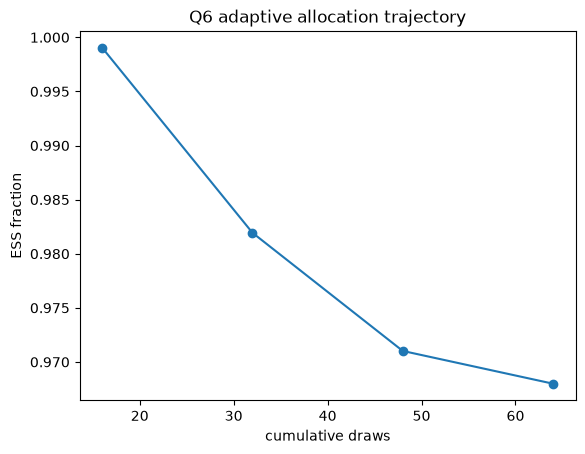

In [3]:
adaptive = runs['adaptive']
history = adaptive.round_history_
plt.plot([row['cumulative_draws'] for row in history], [row['effective_sample_size_fraction'] for row in history], marker='o')
plt.xlabel('cumulative draws')
plt.ylabel('ESS fraction')
plt.title('Q6 adaptive allocation trajectory')
plt.show()
# Add the intentionally uncorrected negative control in a separate implementation.


## Conclusion from the executed starter run

**Status: not falsified, but no adaptive benefit was observed.** At 64 draws, adaptive BPMA had log loss 0.4130 versus 0.4093 for prior sampling and ESS fraction 0.968 versus 0.998. Family masses were reasonably similar, so this run does not show an obvious target distortion, but it also does not support improved quality per budget. Replicated matched-budget runs are needed.